In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import umap
import hyperopt
import hdbscan

In [3]:
import json

with open("GWTC-3.json","r") as file: 
    data = json.load(file)

# number of events
print(f"Number of events: {len(data['events'])}")

Number of events: 93


In [4]:
tidy_data = []
for event_id, event in data['events'].items():
    redshift = event.get('redshift')
    distance = event.get('luminosity_distance')
    mass_1 = event.get('mass_1_source')
    mass_2 = event.get('mass_2_source')
    total_mass = event.get('total_mass_source')
    final_mass = event.get('final_mass_source')
    chirp_mass = event.get('chirp_mass_source')
    snr = event.get('network_matched_filter_snr')
    spin = event.get('chi_eff')
    
    # Only exclude if Mass 1 or Mass 2 is missing
    if mass_1 is not None and mass_2 is not None:
        tidy_data.append({
            "Event ID": event_id,
            "Redshift": redshift,
            "Distance (Mpc)": distance,
            "Mass 1 (M☉)": mass_1,
            "Mass 2 (M☉)": mass_2,
            "Total Mass (M☉)": total_mass,
            "Final Mass (M☉)": final_mass,
            "Chirp Mass (M☉)": chirp_mass,
            "SNR": snr,
            "Effective Spin": spin
        })

# Convert to DataFrame
tidy_df = pd.DataFrame(tidy_data)
tidy_df

,Event ID,Redshift,Distance (Mpc),Mass 1 (M☉),Mass 2 (M☉),Total Mass (M☉),Final Mass (M☉),Chirp Mass (M☉),SNR,Effective Spin
0,GW200322_091133-v1,0.59,3500.0,38.0,11.3,50.0,48.0,15.00,4.5,0.27
1,GW200316_215756-v1,0.22,1120.0,13.1,7.8,21.2,20.2,8.75,10.3,0.13
2,GW200311_115853-v1,0.23,1170.0,34.2,27.7,61.9,59.0,26.60,17.8,-0.02
3,GW200308_173609-v1,1.04,7100.0,60.0,24.0,92.0,88.0,34.00,4.7,0.16
4,GW200306_093714-v1,0.38,2100.0,28.3,14.8,43.9,41.7,17.50,7.8,0.32
...,...,...,...,...,...,...,...,...,...,...
85,GW170608-v3,0.07,320.0,11.0,7.6,NaN,17.8,7.90,15.4,0.03
86,GW170104-v2,0.20,990.0,30.8,20.0,NaN,48.9,21.40,13.8,-0.04
87,GW151226-v2,0.09,450.0,13.7,7.7,NaN,20.5,8.90,13.1,0.18
88,GW151012-v3,0.21,1080.0,23.2,13.6,NaN,35.6,15.20,10.0,0.05


In [5]:
# Check total missing values per column
tidy_df.isnull().sum()

Event ID            0
Redshift            0
Distance (Mpc)      0
Mass 1 (M☉)         0
Mass 2 (M☉)         0
Total Mass (M☉)    11
Final Mass (M☉)     1
Chirp Mass (M☉)     0
SNR                 0
Effective Spin      0
dtype: int64

In [6]:
# Rows where Total Mass is NOT missing (for training)
df_train = tidy_df[tidy_df['Total Mass (M☉)'].notnull()]

# Features and target
X_train = df_train[['Mass 1 (M☉)', 'Mass 2 (M☉)']]
y_train = df_train['Total Mass (M☉)']

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
# Rows where Total Mass IS missing
df_missing = tidy_df[tidy_df['Total Mass (M☉)'].isnull()]
X_missing = df_missing[['Mass 1 (M☉)', 'Mass 2 (M☉)']]

# Make predictions
predicted_total_mass = model.predict(X_missing)

# Fill the missing values with predictions
tidy_df.loc[tidy_df['Total Mass (M☉)'].isnull(), 'Total Mass (M☉)'] = predicted_total_mass

In [8]:
from sklearn.metrics import r2_score

y_pred_train = model.predict(X_train)
r2 = r2_score(y_train, y_pred_train)
print(f"R-squared: {r2:.4f}")

R-squared: 0.9991


In [9]:
# Check total missing values per column again
tidy_df.isnull().sum()

Event ID           0
Redshift           0
Distance (Mpc)     0
Mass 1 (M☉)        0
Mass 2 (M☉)        0
Total Mass (M☉)    0
Final Mass (M☉)    1
Chirp Mass (M☉)    0
SNR                0
Effective Spin     0
dtype: int64

In [10]:
# Prepare training data where Final Mass is present
df_train_final = tidy_df[tidy_df['Final Mass (M☉)'].notnull()]
X_train_final = df_train_final[['Total Mass (M☉)']]
y_train_final = df_train_final['Final Mass (M☉)']

# Fit linear regression
from sklearn.linear_model import LinearRegression
model_final = LinearRegression()
model_final.fit(X_train_final, y_train_final)

# Predict missing Final Mass
df_missing_final = tidy_df[tidy_df['Final Mass (M☉)'].isnull()]
X_missing_final = df_missing_final[['Total Mass (M☉)']]
predicted_final_mass = model_final.predict(X_missing_final)

# Fill missing value
tidy_df.loc[tidy_df['Final Mass (M☉)'].isnull(), 'Final Mass (M☉)'] = predicted_final_mass

In [11]:
spin = event.get('chi_eff')

if mass_1 is not None and mass_2 is not None:
    tidy_data.append({
        "Event ID": event_id,
        "Redshift": redshift,
        "Distance (Mpc)": distance,
        "Mass 1 (M☉)": mass_1,
        "Mass 2 (M☉)": mass_2,
        "Total Mass (M☉)": total_mass,
        "Final Mass (M☉)": final_mass,
        "Chirp Mass (M☉)": chirp_mass,
        "SNR": snr,
        "Effective Spin": spin
    })

In [12]:
# Check total missing values per column
tidy_df.isnull().sum()

Event ID           0
Redshift           0
Distance (Mpc)     0
Mass 1 (M☉)        0
Mass 2 (M☉)        0
Total Mass (M☉)    0
Final Mass (M☉)    0
Chirp Mass (M☉)    0
SNR                0
Effective Spin     0
dtype: int64

In [13]:
# Select only numeric columns
numeric_cols = tidy_df.select_dtypes(include='number')

# Compute five-number summary + mean
summary = numeric_cols.describe().loc[['min', '25%', '50%', '75%', 'max']]
summary.loc['mean'] = numeric_cols.mean()

# Reorder the summary to match five-number + mean format
summary = summary.loc[['min', '25%', '50%', 'mean', '75%', 'max']]

# Display
summary.T  # Transpose for easier reading

,min,25%,50%,mean,75%,max
Redshift,0.010000,0.190,0.295000,0.364444,0.5475,1.18
Distance (Mpc),40.000000,930.000,1580.000000,2117.111111,3257.5000,8280.00
Mass 1 (M☉),1.460000,21.400,35.500000,35.355111,43.1000,105.50
Mass 2 (M☉),1.170000,8.325,23.550000,21.744556,29.0000,76.00
Total Mass (M☉),2.854084,31.625,58.467812,57.242314,73.2750,182.30
Final Mass (M☉),2.800000,30.600,55.900000,54.714951,70.0500,172.90
Chirp Mass (M☉),1.186000,9.425,24.450000,23.302067,30.8000,76.00
SNR,4.500000,9.025,10.850000,12.314444,13.3500,33.00
Effective Spin,-0.290000,-0.030,0.055000,0.076667,0.1575,0.68


data is good to go

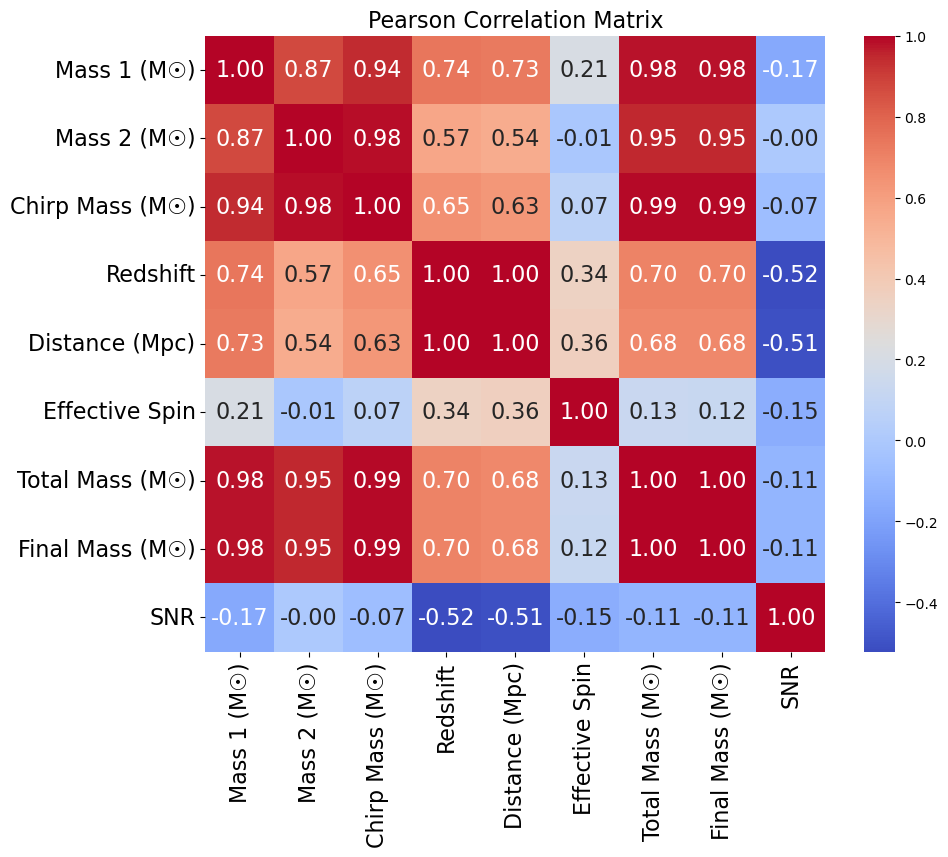

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate Pearson correlation matrix
corr_matrix = tidy_df[['Mass 1 (M☉)', 'Mass 2 (M☉)', 'Chirp Mass (M☉)', 
                       'Redshift', 'Distance (Mpc)', 'Effective Spin', 
                       'Total Mass (M☉)', 'Final Mass (M☉)', 'SNR']].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 16})
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [15]:
features = ['Mass 1 (M☉)', 'Mass 2 (M☉)', 'Chirp Mass (M☉)', 
            'Redshift', 'Distance (Mpc)', 'Effective Spin', 
            'Total Mass (M☉)', 'Final Mass (M☉)', 'SNR']

X = tidy_df[features]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

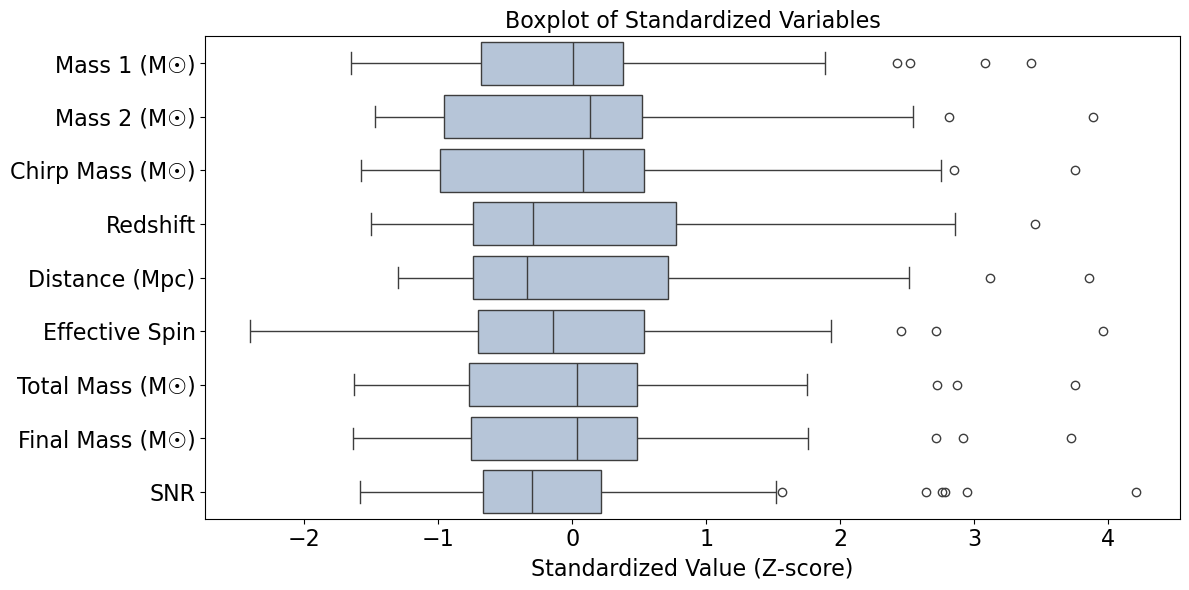

In [16]:
standardized_df = pd.DataFrame(X_scaled, columns=features)

plt.figure(figsize=(12, 6))
sns.boxplot(data=standardized_df, orient='h', color="lightsteelblue")

plt.title("Boxplot of Standardized Variables", fontsize=16)
plt.xlabel("Standardized Value (Z-score)", fontsize=16)
plt.ylabel("")  # Optional: remove ylabel
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

PCA

In [17]:
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

# Convert to DataFrame for convenience
X_pca_df = pd.DataFrame(X_pca_full, columns=[f'PC{i+1}' for i in range(X_pca_full.shape[1])])

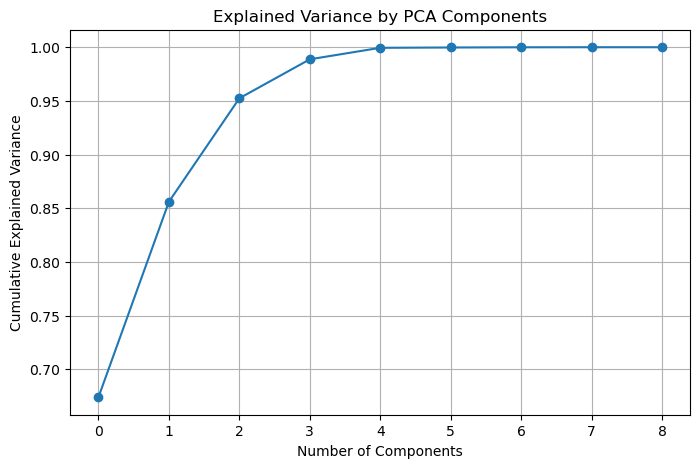

In [18]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

In [19]:
explained_variance_ratio = pca.explained_variance_ratio_

# Create the table
pca_table = pd.DataFrame({
    "Principal Component": np.arange(1, len(pca.explained_variance_) + 1),
    "Eigenvalue": pca.explained_variance_,
    "Explained Variance (%)": pca.explained_variance_ratio_ * 100,
    "Cumulative Variance (%)": np.cumsum(pca.explained_variance_ratio_) * 100
})

# Display the table
print(pca_table.round(3))

   Principal Component  Eigenvalue  Explained Variance (%)  \
0                    1       6.134                  67.395   
1                    2       1.657                  18.210   
2                    3       0.877                   9.638   
3                    4       0.331                   3.631   
4                    5       0.097                   1.071   
5                    6       0.003                   0.029   
6                    7       0.002                   0.020   
7                    8       0.000                   0.005   
8                    9       0.000                   0.000   

   Cumulative Variance (%)  
0                   67.395  
1                   85.605  
2                   95.243  
3                   98.875  
4                   99.946  
5                   99.975  
6                   99.994  
7                  100.000  
8                  100.000  


UMAP

/home/lulu6277/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lulu6277/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lulu6277/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lulu6277/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lulu6277/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lulu6277/.local/lib/py

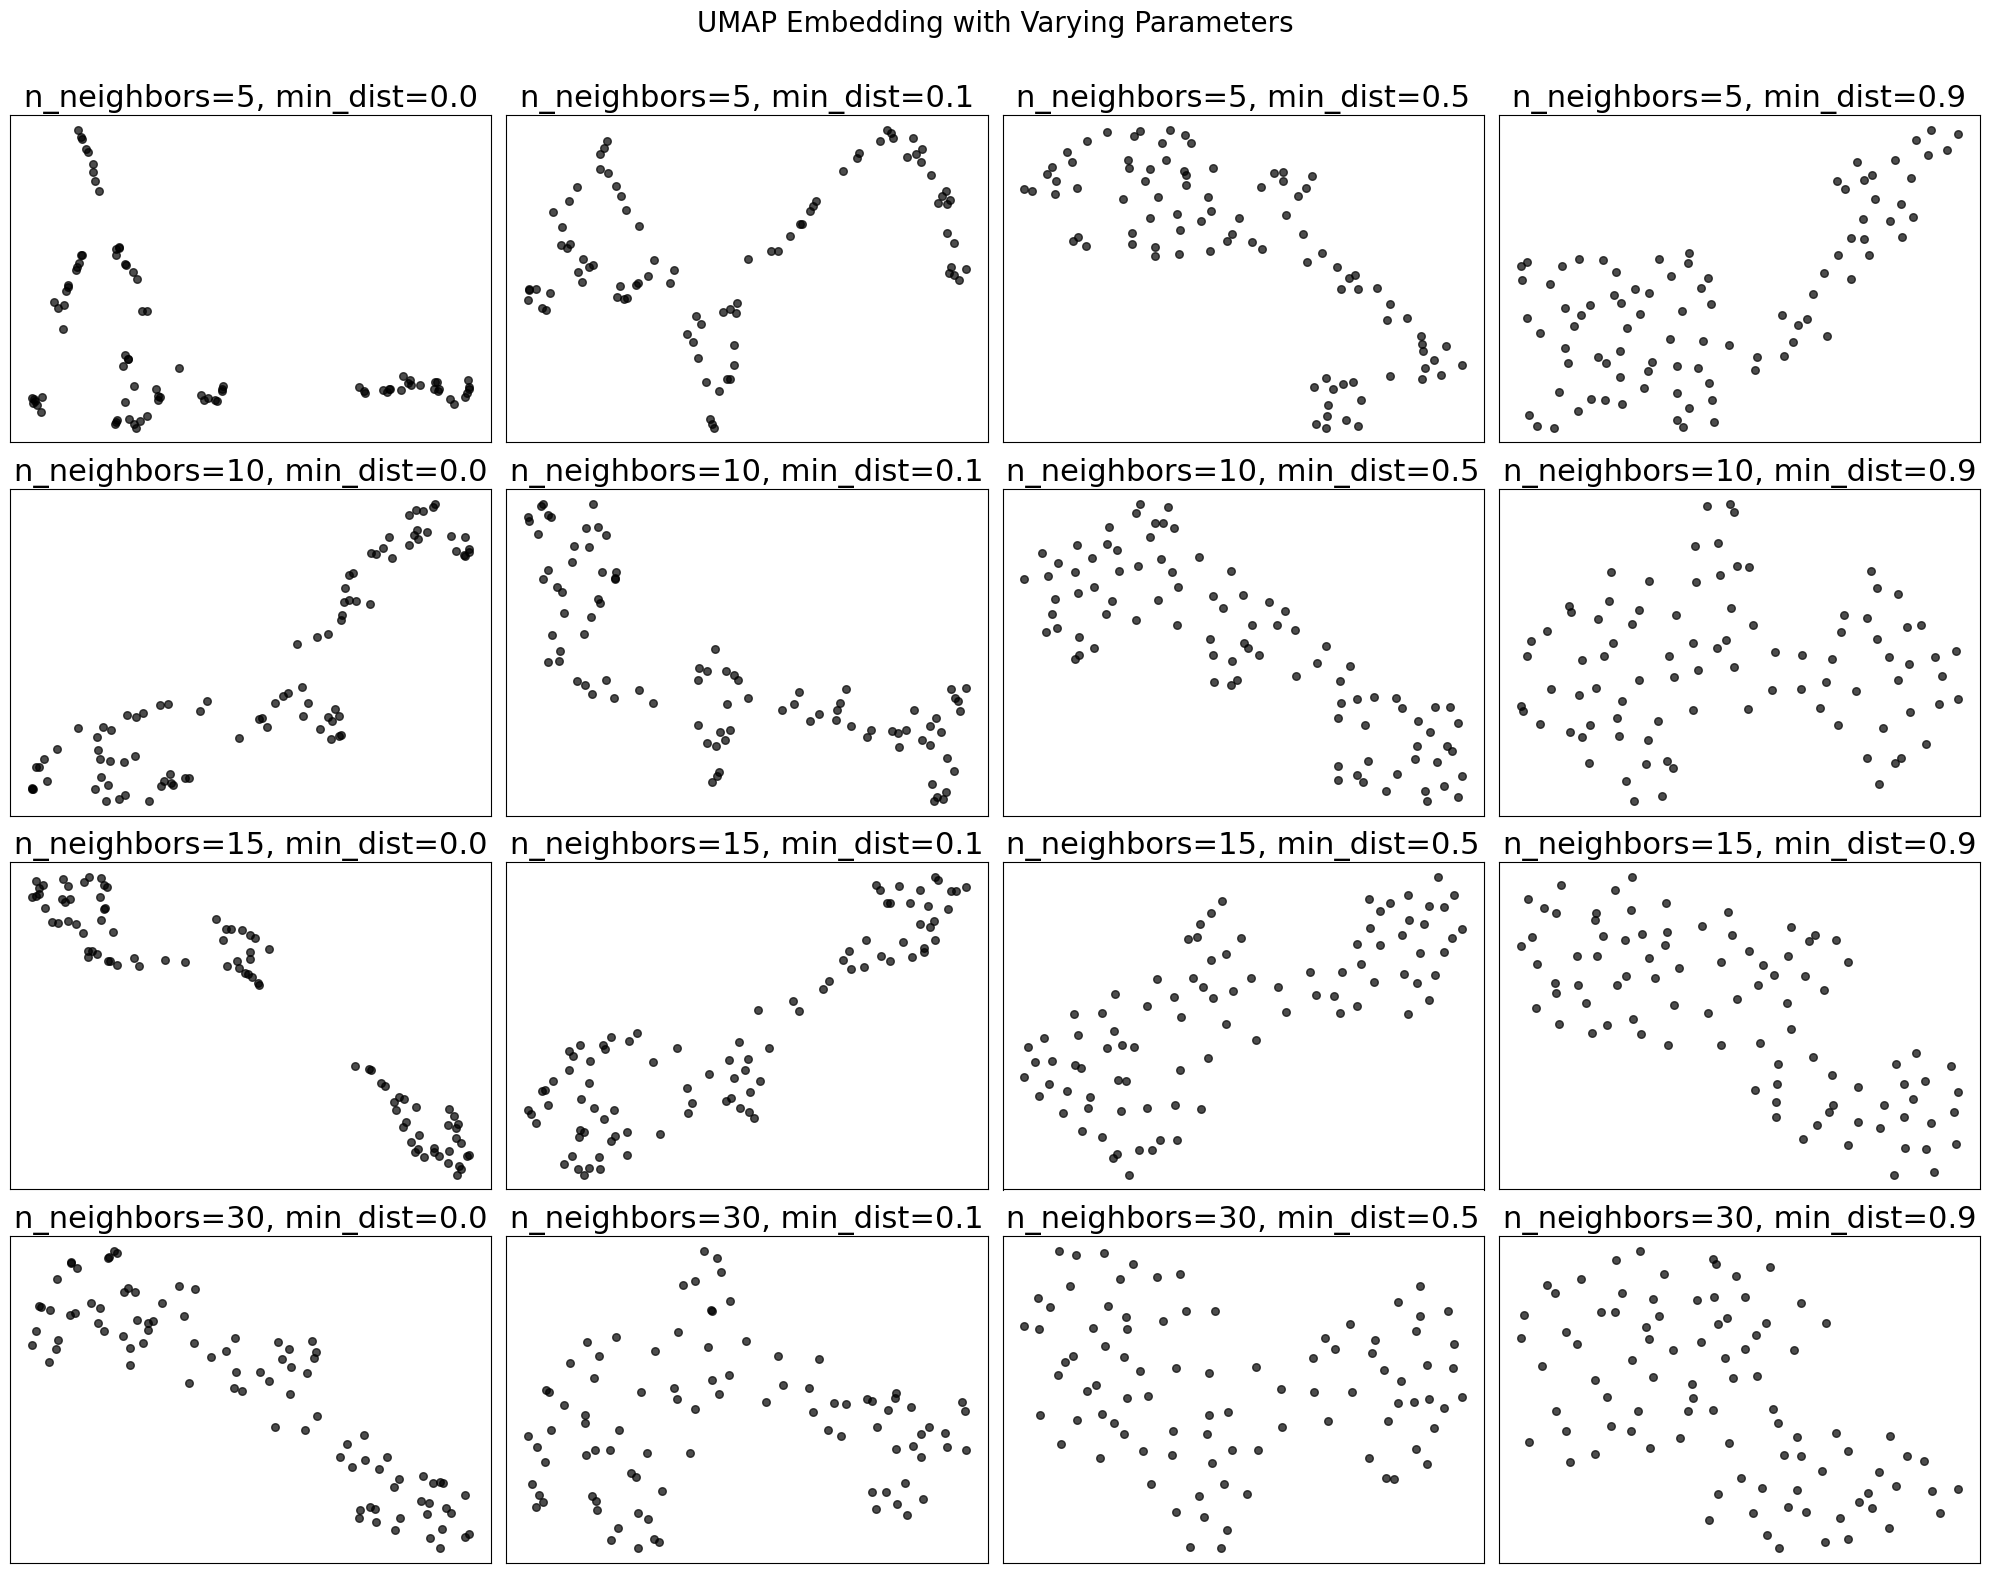

In [20]:
# Parameter grid
n_neighbors_list = [5, 10, 15, 30]
min_dist_list = [0.0, 0.1, 0.5, 0.9]

# UMAP scatter plots
fig, axes = plt.subplots(len(n_neighbors_list), len(min_dist_list), figsize=(20, 16))
fig.suptitle("UMAP Embedding with Varying Parameters", fontsize=20)

for i, n_neighbors in enumerate(n_neighbors_list):
    for j, min_dist in enumerate(min_dist_list):
        reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, random_state=42)
        embedding = reducer.fit_transform(X_scaled)
        ax = axes[i, j]
        ax.scatter(embedding[:, 0], embedding[:, 1], s=30, c='black', alpha=0.7)
        ax.set_title(f"n_neighbors={n_neighbors}, min_dist={min_dist}",fontsize=22)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [21]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.0, n_components=2, random_state=42)
X_umap_best = reducer.fit_transform(X_scaled)

/home/lulu6277/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lulu6277/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


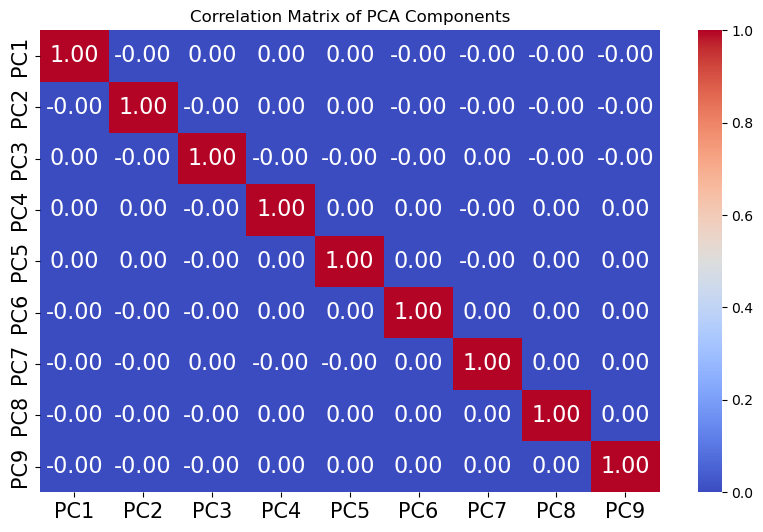

In [22]:
# checking the multicolinearity
# PCA output: assume X_pca_full is (n_samples, n_components)
df_pca = pd.DataFrame(X_pca_full, columns=[f'PC{i+1}' for i in range(X_pca_full.shape[1])])

# UMAP output: assume X_umap_best is (n_samples, 2)
df_umap = pd.DataFrame(X_umap_best, columns=[f'UMAP{i+1}' for i in range(X_umap_best.shape[1])])

# --- PCA Correlation Matrix ---
plt.figure(figsize=(10, 6))
sns.heatmap(df_pca.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 16})
plt.title("Correlation Matrix of PCA Components")
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

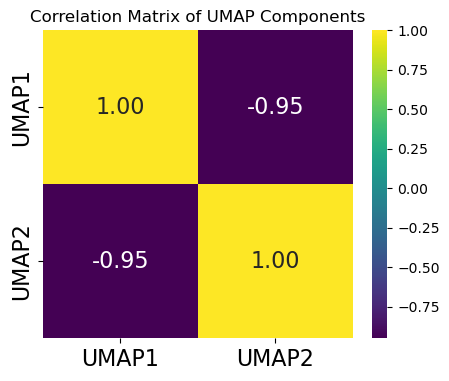

In [23]:
# --- UMAP Correlation Matrix ---
plt.figure(figsize=(5, 4))
sns.heatmap(df_umap.corr(), annot=True, cmap="viridis", fmt=".2f", annot_kws={"size": 16})
plt.title("Correlation Matrix of UMAP Components")
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

***K-Means***

determining the number of k using pca

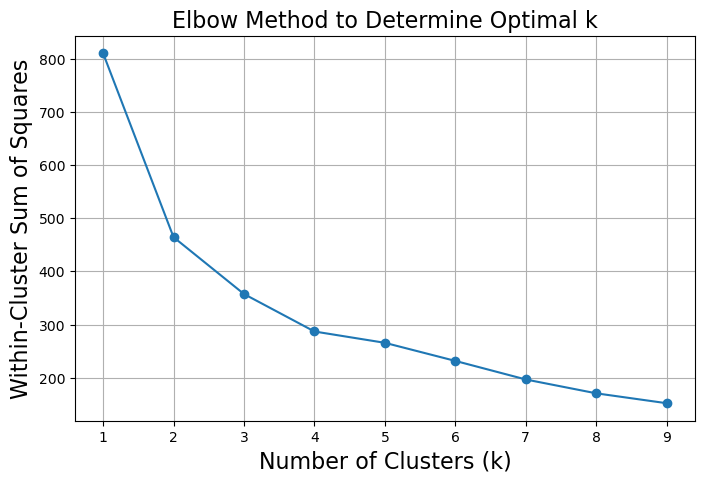

In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca_df)  # or X_umap
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (k)", fontsize=16)
plt.ylabel("Within-Cluster Sum of Squares", fontsize=16)
plt.title("Elbow Method to Determine Optimal k", fontsize=16)
plt.grid()
plt.show()

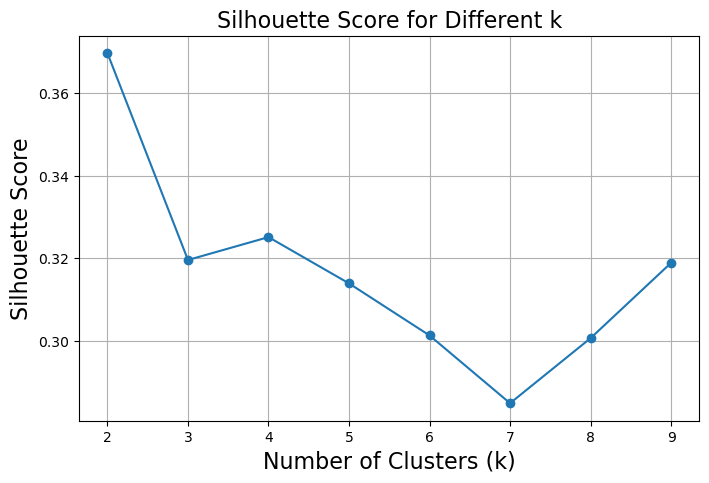

In [25]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 10)  # must start from 2

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca_df)
    score = silhouette_score(X_pca_df, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters (k)", fontsize=16)
plt.ylabel("Silhouette Score", fontsize=16)
plt.title("Silhouette Score for Different k", fontsize=16)
plt.grid()
plt.show()

determining the number of k using umap

In [26]:
# Define parameter grid
n_neighbors_list = [5, 10, 15, 30]
min_dist_list = [0.0, 0.1, 0.5, 0.9]

# Store results
umap_kmeans_results = []

# Loop through all combinations
for n_neighbors in n_neighbors_list:
    for min_dist in min_dist_list:
        reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42)
        X_umap = reducer.fit_transform(X_scaled)

        for k in [3, 4,5,6,7,8,9]:
            kmeans = KMeans(n_clusters=k, random_state=42)
            labels = kmeans.fit_predict(X_umap)
            silhouette = silhouette_score(X_umap, labels)

            umap_kmeans_results.append({
                'n_neighbors': n_neighbors,
                'min_dist': min_dist,
                'k': k,
                'silhouette_score': silhouette
            })

# Create DataFrame of results
umap_kmeans_df = pd.DataFrame(umap_kmeans_results)

# Show best configuration
best_config = umap_kmeans_df.loc[umap_kmeans_df['silhouette_score'].idxmax()]
print("Best UMAP + KMeans Configuration:")
print(best_config)

# View all results
umap_kmeans_df.sort_values(by='silhouette_score', ascending=False)


/home/lulu6277/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lulu6277/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lulu6277/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lulu6277/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/lulu6277/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lulu6277/.local/lib/py

Best UMAP + KMeans Configuration:
n_neighbors         15.000000
min_dist             0.000000
k                    3.000000
silhouette_score     0.728651
Name: 56, dtype: float64


,n_neighbors,min_dist,k,silhouette_score
56,15,0.0,3,0.728651
5,5,0.0,8,0.665435
6,5,0.0,9,0.649508
57,15,0.0,4,0.637006
35,10,0.1,3,0.636767
...,...,...,...,...
110,30,0.9,8,0.341630
109,30,0.9,7,0.339515
103,30,0.5,8,0.339296
104,30,0.5,9,0.335645


/home/lulu6277/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lulu6277/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


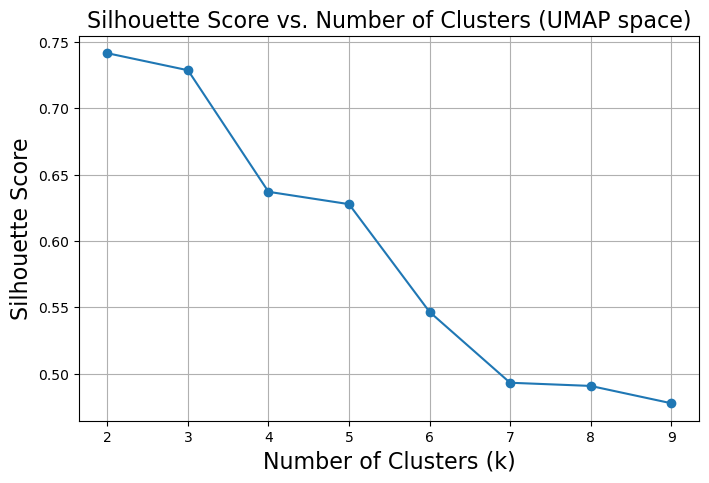

In [27]:
umap_model = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.0, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# Step 2: Try different k
sil_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_umap)
    sil_scores.append(silhouette_score(X_umap, labels))

# Step 3: Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o')
plt.title("Silhouette Score vs. Number of Clusters (UMAP space)", fontsize=16)
plt.xlabel("Number of Clusters (k)", fontsize=16)
plt.ylabel("Silhouette Score", fontsize=16)
plt.grid()
plt.show()

/home/lulu6277/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lulu6277/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


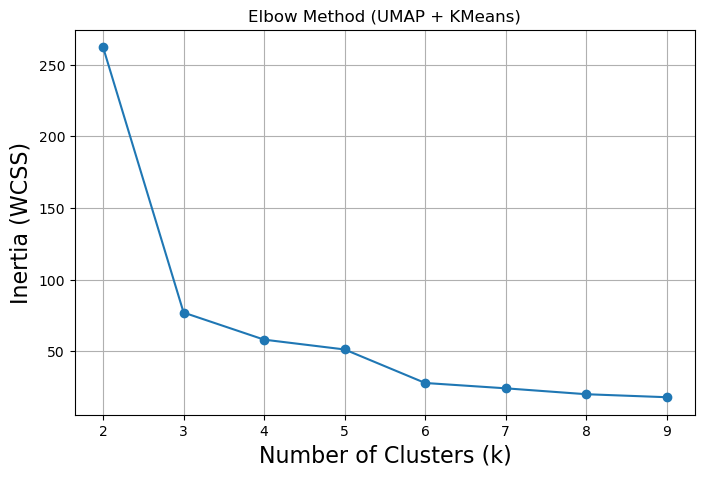

In [28]:
#elbow
inertias = []
k_range = range(2, 10)

# UMAP-transformed data (2D)
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.0, random_state=42).fit_transform(X_scaled)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_umap)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title("Elbow Method (UMAP + KMeans)")
plt.xlabel("Number of Clusters (k)", fontsize=16)
plt.ylabel("Inertia (WCSS)", fontsize=16)
plt.grid()
plt.show()

so the best number of k should be 3 or 4

In [29]:
# PCA + K-Means
for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    tidy_df[f'PCA_KMeans_{k}'] = kmeans.fit_predict(X_pca_df)

In [30]:
# UMAP + K-Means
for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    tidy_df[f'UMAP_KMeans_{k}'] = kmeans.fit_predict(X_umap_best)

In [31]:
for k in [3, 4]:
    score_pca = silhouette_score(X_pca_df, tidy_df[f'PCA_KMeans_{k}'])
    score_umap = silhouette_score(X_umap_best, tidy_df[f'UMAP_KMeans_{k}'])
    print(f"PCA + KMeans (k={k}): Silhouette = {score_pca:.3f}")
    print(f"UMAP + KMeans (k={k}): Silhouette = {score_umap:.3f}")

PCA + KMeans (k=3): Silhouette = 0.320
UMAP + KMeans (k=3): Silhouette = 0.729
PCA + KMeans (k=4): Silhouette = 0.325
UMAP + KMeans (k=4): Silhouette = 0.637


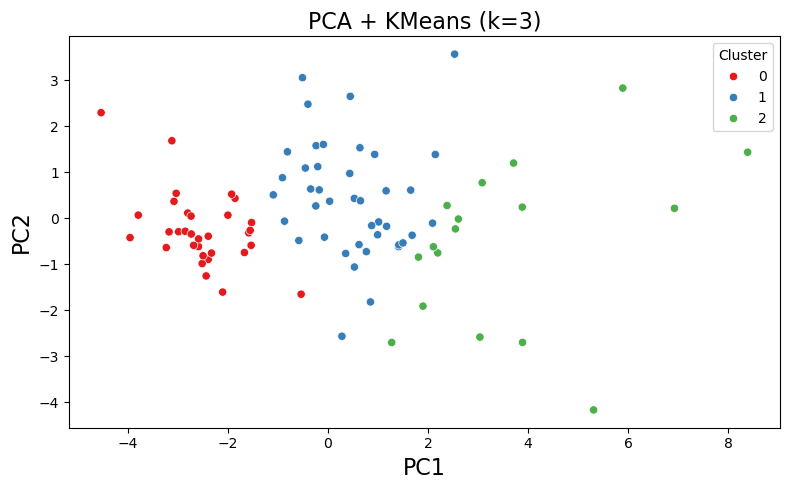

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2D PCA projection for visualization
X_pca_2d = X_pca_df[['PC1', 'PC2']].values

# Scatterplot without number text on points
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1],
                hue=tidy_df['PCA_KMeans_3'], palette="Set1", legend='full')

plt.title("PCA + KMeans (k=3)", fontsize=16)
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


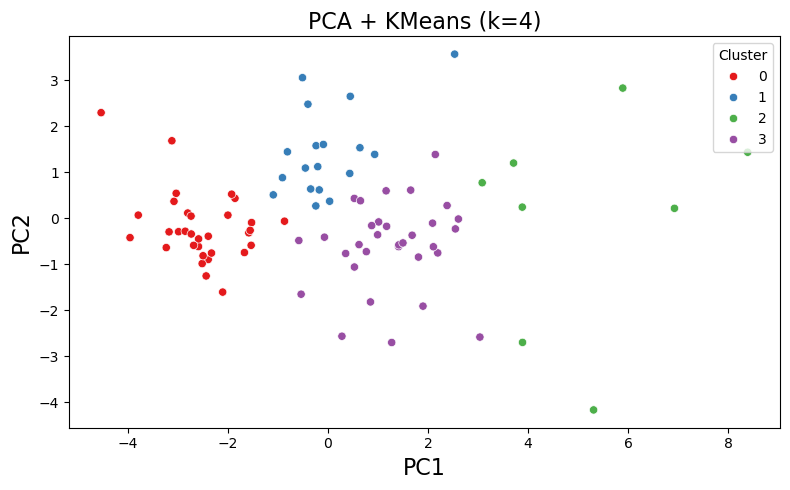

In [33]:

# PCA + KMeans (k=4)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=tidy_df['PCA_KMeans_4'], palette="Set1")
plt.title("PCA + KMeans (k=4)", fontsize=16)
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)
plt.legend(title='Cluster')  # Keep this line to show the legend
plt.tight_layout()
plt.show()


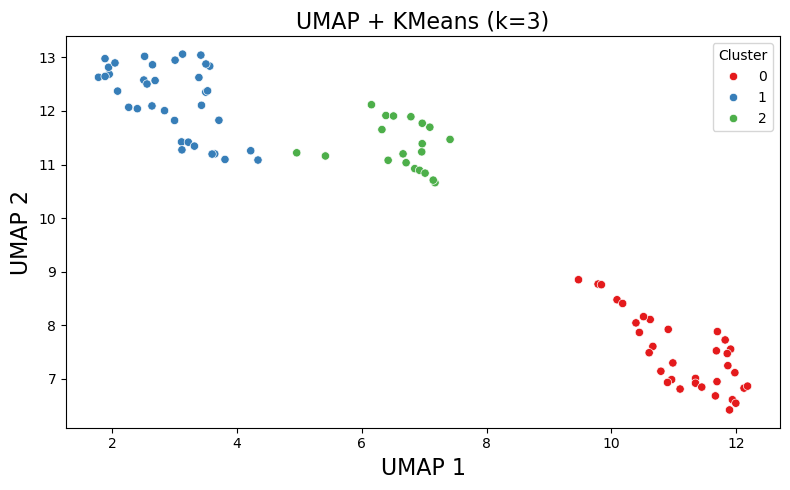

In [34]:
# UMAP + KMeans (k=3)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_umap_best[:, 0], y=X_umap_best[:, 1], 
                hue=tidy_df['UMAP_KMeans_3'], palette="Set1")

plt.title("UMAP + KMeans (k=3)", fontsize=16)
plt.xlabel("UMAP 1", fontsize=16)
plt.ylabel("UMAP 2", fontsize=16)
plt.legend(title='Cluster')  # or .remove() if you want no legend
plt.tight_layout()
plt.show()


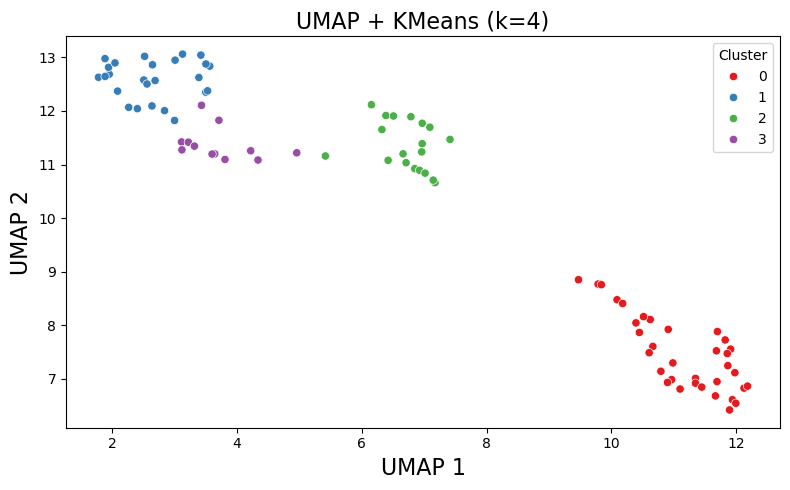

In [35]:
# UMAP + KMeans (k=4) - Standalone
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_umap_best[:, 0], y=X_umap_best[:, 1], 
                hue=tidy_df['UMAP_KMeans_4'], palette="Set1")

plt.title("UMAP + KMeans (k=4)", fontsize=16)
plt.xlabel("UMAP 1", fontsize=16)
plt.ylabel("UMAP 2", fontsize=16)
plt.legend(title='Cluster')  # or .remove() to hide legend
plt.tight_layout()
plt.show()


/home/lulu6277/.local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/lulu6277/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


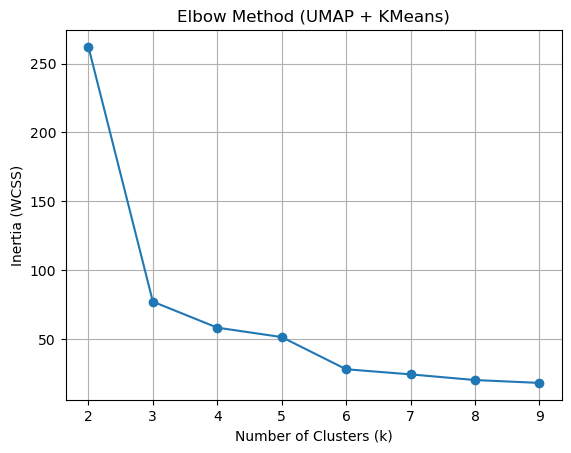

In [36]:
#elbow
inertias = []
k_range = range(2, 10)

# UMAP-transformed data (2D)
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.0, random_state=42).fit_transform(X_scaled)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_umap)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(k_range, inertias, marker='o')
plt.title("Elbow Method (UMAP + KMeans)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.grid()
plt.show()

***DBSCAN***

In [37]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

k = 3 # min_samples
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_pca_np)
distances, indices = nbrs.kneighbors(X_pca_np)

# take k-th nearest distance
k_distances = distances[:, k-1]
k_distances = np.sort(k_distances)

plt.plot(k_distances)
plt.title("k-distance Graph (PCA space)")
plt.xlabel("Sorted Points")
plt.ylabel(f"Distance to {k}th Nearest Neighbor")
plt.grid()
plt.show()


NameError: name 'X_pca_np' is not defined

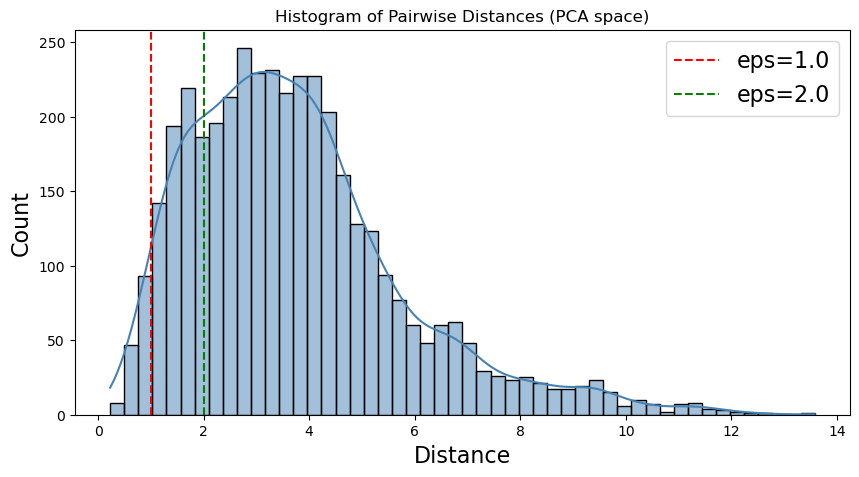

In [48]:
from sklearn.metrics import pairwise_distances
X_pca_np = X_pca_df.values
distances = pairwise_distances(X_pca_np)
flat_distances = distances[np.triu_indices_from(distances, k=1)]

plt.figure(figsize=(10, 5))
sns.histplot(flat_distances, bins=50, kde=True, color="steelblue")
plt.axvline(x=1.0, color='r', linestyle='--', label='eps=1.0')
plt.axvline(x=2.0, color='g', linestyle='--', label='eps=2.0')
plt.xlabel("Distance", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.title("Histogram of Pairwise Distances (PCA space)")
plt.legend(fontsize=16)
plt.show()

In [49]:
print(len(X_pca_np))

90


In [50]:
# PCA + DBSCAN
X_pca_np = X_pca_df.values

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import hdbscan

for eps in [1.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0]:
    for min_samples in [3, 5, 7, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_pca_np)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters < 2:
            print(f"eps={eps}, min_samples={min_samples} → Not enough clusters")
            continue

        sil = silhouette_score(X_pca_np, labels)
        dbcv = hdbscan.validity.validity_index(X_pca_np, labels)
        print(f"eps={eps}, min_samples={min_samples} → Clusters={n_clusters}, Silhouette={sil:.3f}, DBCV={dbcv:.3f}")


eps=1.0, min_samples=3 → Clusters=2, Silhouette=0.179, DBCV=0.171
eps=1.0, min_samples=5 → Clusters=2, Silhouette=-0.006, DBCV=0.119
eps=1.0, min_samples=7 → Clusters=3, Silhouette=-0.007, DBCV=0.190
eps=1.0, min_samples=10 → Clusters=2, Silhouette=-0.083, DBCV=0.209
eps=2.5, min_samples=3 → Not enough clusters
eps=2.5, min_samples=5 → Not enough clusters
eps=2.5, min_samples=7 → Not enough clusters
eps=2.5, min_samples=10 → Not enough clusters
eps=3.0, min_samples=3 → Not enough clusters
eps=3.0, min_samples=5 → Not enough clusters
eps=3.0, min_samples=7 → Not enough clusters
eps=3.0, min_samples=10 → Not enough clusters
eps=3.5, min_samples=3 → Not enough clusters
eps=3.5, min_samples=5 → Not enough clusters
eps=3.5, min_samples=7 → Not enough clusters
eps=3.5, min_samples=10 → Not enough clusters
eps=4.0, min_samples=3 → Not enough clusters
eps=4.0, min_samples=5 → Not enough clusters
eps=4.0, min_samples=7 → Not enough clusters
eps=4.0, min_samples=10 → Not enough clusters
eps=5.0,

In [51]:
import numpy as np
from sklearn.cluster import DBSCAN

eps = 2.8
min_samples = 10

dbscan = DBSCAN(eps=2.8, min_samples=10)

labels = dbscan.fit_predict(X_pca_np)
unique_labels, counts = np.unique(labels, return_counts=True)

for label, count in zip(unique_labels, counts):
    print(f"Cluster {label}: {count} points")

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = list(labels).count(-1)

print(f"\nClusters found: {n_clusters}")
print(f"Outliers: {n_outliers}")

Cluster -1: 5 points
Cluster 0: 85 points

Clusters found: 1
Outliers: 5


In [52]:
tidy_df['PCA_DBSCAN'] = labels

# Show event IDs of DBSCAN outliers in PCA
outliers_pca = tidy_df[tidy_df['PCA_DBSCAN'] == -1][['Event ID']]
outliers_pca.reset_index(drop=True, inplace=True)
print("Outlier Event IDs (PCA + DBSCAN):")
print(outliers_pca)

Outlier Event IDs (PCA + DBSCAN):
             Event ID
0  GW200220_061928-v1
1  GW190521_030229-v4
2  GW190426_190642-v1
3  GW190403_051519-v1
4         GW170817-v3


In [53]:
db_final = DBSCAN(eps=2.8, min_samples=int(10))
labels_final = db_final.fit_predict(X_pca_np)

n_clusters = len(set(labels_final)) - (1 if -1 in labels_final else 0)
n_outliers = list(labels_final).count(-1)

print(f"Clusters: {n_clusters}, Outliers: {n_outliers}")

# You can still visualize and discuss even if only 1 cluster
try:
    sil_score_final = silhouette_score(X_pca_np, labels_final)
    dbcv_final = validity_index(X_pca_np, labels_final)
    print(f"Silhouette Score: {sil_score_final}")
    print(f"DBCV Score: {dbcv_final}")
except Exception as e:
    print("Silhouette/DBCV cannot be computed:", e)

Clusters: 1, Outliers: 5
Silhouette Score: 0.5196273835772995
DBCV Score: nan


/home/lulu6277/.local/lib/python3.11/site-packages/hdbscan/validity.py:407: RuntimeWarning: invalid value encountered in scalar divide
  (min_density_sep - density_sparseness[i]) /


In [54]:
# Convert labels to a Series for easier filtering
outlier_indices = np.where(labels_final == -1)[0]

# Show the rows in your original data (tidy_df) that are outliers
outliers_df = tidy_df.iloc[outlier_indices]

# Display the outliers
print(f"Found {len(outliers_df)} outliers:")
display(outliers_df)

Found 5 outliers:


,Event ID,Redshift,Distance (Mpc),Mass 1 (M☉),Mass 2 (M☉),Total Mass (M☉),Final Mass (M☉),Chirp Mass (M☉),SNR,Effective Spin,PCA_KMeans_3,PCA_KMeans_4,UMAP_KMeans_3,UMAP_KMeans_4,PCA_DBSCAN,UMAP_DBSCAN
9,GW200220_061928-v1,0.90,6000.0,87.00,61.00,148.000000,141.0,62.000,7.2,0.06,2,2,1,1,-1,0
64,GW190521_030229-v4,0.56,3310.0,98.40,57.20,153.100000,147.4,63.300,14.3,-0.14,2,2,1,1,-1,0
71,GW190426_190642-v1,0.73,4580.0,105.50,76.00,182.300000,172.9,76.000,8.7,0.23,2,2,1,1,-1,0
78,GW190403_051519-v1,1.18,8280.0,85.00,20.00,106.600000,102.2,34.000,7.6,0.68,2,2,1,3,-1,0
81,GW170817-v3,0.01,40.0,1.46,1.27,2.854084,2.8,1.186,33.0,0.00,0,0,0,0,-1,1


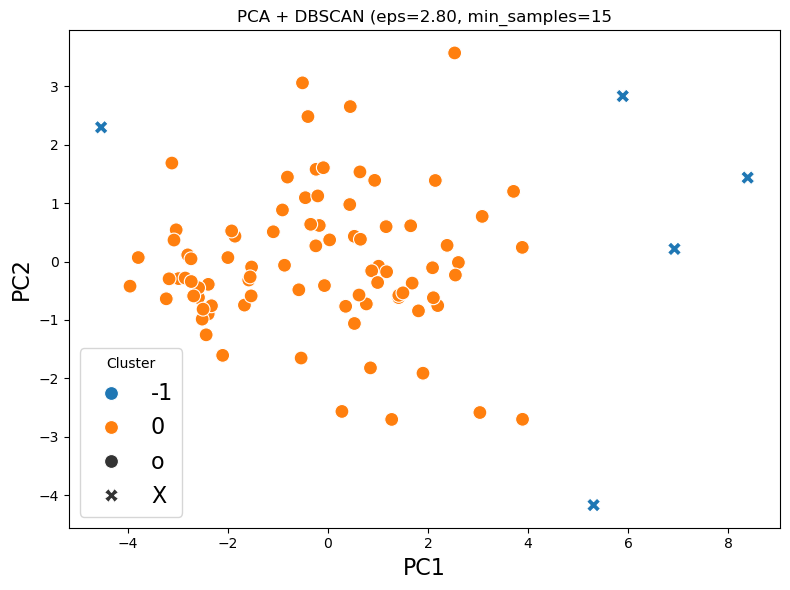

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
best_eps=2.8
# Assume X_pca_df has the PCA components as columns (PC1, PC2, ...)
# and labels_final is your DBSCAN result
df_vis = X_pca_df.iloc[:, :2].copy()  # take only PC1 and PC2
df_vis['cluster'] = labels_final

# Create the scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_vis.columns[0], y=df_vis.columns[1],
    hue='cluster', palette='tab10', data=df_vis,
    style=df_vis['cluster'].apply(lambda x: 'X' if x == -1 else 'o'),
    s=100
)
plt.title(f"PCA + DBSCAN (eps={best_eps:.2f}, min_samples=15")
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)
plt.legend(title="Cluster", fontsize=16)
plt.tight_layout()
plt.show()

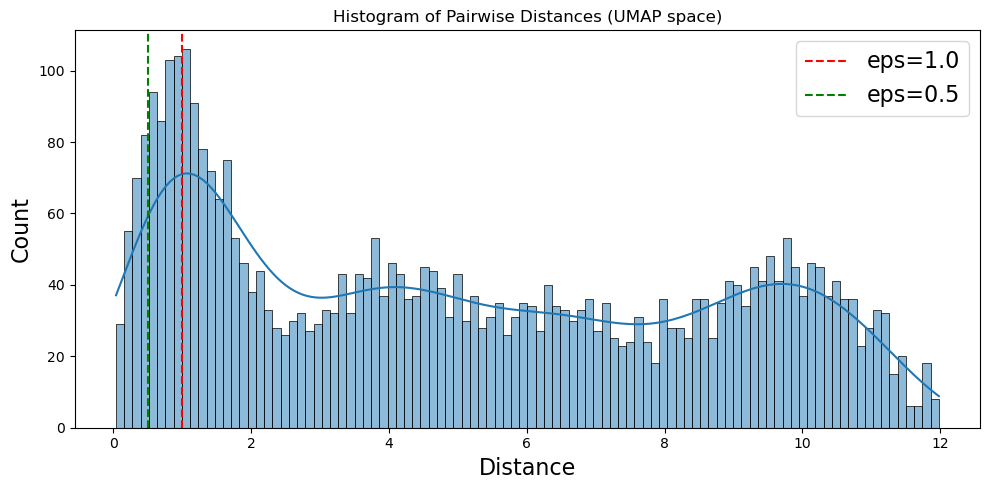

In [56]:
from sklearn.metrics import pairwise_distances

dists = pairwise_distances(X_umap_best)
dists_flat = dists[np.triu_indices_from(dists, k=1)]  # upper triangle

plt.figure(figsize=(10, 5))
sns.histplot(dists_flat, bins=100, kde=True)
plt.axvline(1.0, color='red', linestyle='--', label='eps=1.0')
plt.axvline(0.5, color='green', linestyle='--', label='eps=0.5')
plt.title("Histogram of Pairwise Distances (UMAP space)")
plt.xlabel("Distance", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

In [62]:
import numpy as np
import pandas as pd
import umap
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from hdbscan.validity import validity_index
import warnings

# === INPUT: standardized data ===
X_std = X_scaled   # replace with your standardized data

# Parameter grids
n_neighbors_values = [5, 10, 15, 30]
min_dist_values = [0.0, 0.1, 0.5, 0.9]
eps_values = np.linspace(0.5, 12.0, 15)
min_samples_values = [3, 5, 7, 10, 12, 15, 20]

results_all = []

# Ignore specific warnings from UMAP and sklearn
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

for n_neighbors in n_neighbors_values:
    for min_dist in min_dist_values:
        # UMAP embedding
        reducer = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=42
        )
        X_umap = reducer.fit_transform(X_std)

        for eps in eps_values:
            for min_samples in min_samples_values:
                dbscan = DBSCAN(eps=eps, min_samples=min_samples)
                labels = dbscan.fit_predict(X_umap)

                # Calculate number of clusters and noise points
                n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
                n_noise = np.sum(labels == -1)

                # Skip invalid clustering
                if n_clusters < 2 or np.all(labels == -1):
                    continue

                try:
                    sil_score = silhouette_score(X_umap, labels)

                    # Validity index requires float64 and stable clusters
                    if n_noise > 0.5 * len(labels):
                        continue  # too much noise, skip
                    dbcv_score = validity_index(X_umap.astype(np.float64), labels)

                    results_all.append({
                        "n_neighbors": n_neighbors,
                        "min_dist": min_dist,
                        "eps": eps,
                        "min_samples": min_samples,
                        "n_clusters": n_clusters,
                        "n_noise": n_noise,
                        "silhouette_score": sil_score,
                        "dbcv_score": dbcv_score
                    })

                    print(f"OK: UMAP(nn={n_neighbors}, md={min_dist}) + DBSCAN(eps={eps:.2f}, min={min_samples}) → "
                          f"clusters={n_clusters}, sil={sil_score:.3f}, dbcv={dbcv_score:.3f}")

                except Exception as e:
                    # Skip invalid configurations gracefully
                    print(f"Skipped: nn={n_neighbors}, md={min_dist}, eps={eps:.2f}, min={min_samples} due to error {e}")
                    continue

# Save all results
df_results = pd.DataFrame(results_all)
df_results.to_csv("umap_dbscan_full_results.csv", index=False)

print("\n=== Total valid runs:", len(df_results))
best = df_results.sort_values("silhouette_score", ascending=False).iloc[0]
print("\n=== Best Combination ===")
print(best)


OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=0.50, min=3) → clusters=10, sil=0.629, dbcv=0.648
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=0.50, min=5) → clusters=10, sil=0.529, dbcv=0.637
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=0.50, min=7) → clusters=6, sil=0.105, dbcv=0.437
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=1.32, min=3) → clusters=3, sil=0.480, dbcv=0.494
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=1.32, min=5) → clusters=3, sil=0.480, dbcv=0.494
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=1.32, min=7) → clusters=3, sil=0.480, dbcv=0.494
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=1.32, min=10) → clusters=2, sil=0.472, dbcv=0.721
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=1.32, min=12) → clusters=3, sil=0.499, dbcv=-0.114
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=1.32, min=15) → clusters=3, sil=0.417, dbcv=0.324
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=2.14, min=3) → clusters=2, sil=0.767, dbcv=0.757
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=2.14, min=5) → clusters=2, sil=0.767, dbcv=0.757
OK: UMAP(nn=5, md=0.0) + DBSCAN(eps=2.14, min=7) → clusters

In [58]:
# UMAP + DBSCAN

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from hdbscan.validity import validity_index
import seaborn as sns
import matplotlib.pyplot as plt

# === INPUT: Replace this with your UMAP-transformed data ===
# Assuming you already have UMAP result saved as `X_umap`
X_input = X_umap.astype(np.float64)  # ensure float64

# === Parameter grid ===
eps_values = np.linspace(0.5, 12.0, 15)  # finer, smaller range for UMAP
min_samples_values = [3, 5, 7, 10, 12, 15, 20]

results = []

# === Grid search ===
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_input)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters < 2:
            print(f"Skipped: eps={eps:.2f}, min_samples={min_samples} (only {n_clusters} cluster)")
            continue

        sil_score = silhouette_score(X_input, labels)
        dbcv_score = validity_index(X_input, labels)

        print(f"OK: eps={eps:.2f}, min_samples={min_samples} → clusters={n_clusters}, sil={sil_score:.3f}, dbcv={dbcv_score:.3f}")

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "silhouette_score": sil_score,
            "dbcv_score": dbcv_score
        })

# === Save and display result ===
df_results = pd.DataFrame(results)
df_results.to_csv("umap_dbscan_results.csv", index=False)
print("Done! Total valid runs:", len(df_results))

OK: eps=0.50, min_samples=3 → clusters=4, sil=-0.446, dbcv=0.100
Skipped: eps=0.50, min_samples=5 (only 0 cluster)
Skipped: eps=0.50, min_samples=7 (only 0 cluster)
Skipped: eps=0.50, min_samples=10 (only 0 cluster)
Skipped: eps=0.50, min_samples=12 (only 0 cluster)
Skipped: eps=0.50, min_samples=15 (only 0 cluster)
Skipped: eps=0.50, min_samples=20 (only 0 cluster)
Skipped: eps=1.32, min_samples=3 (only 1 cluster)
Skipped: eps=1.32, min_samples=5 (only 1 cluster)
Skipped: eps=1.32, min_samples=7 (only 1 cluster)
OK: eps=1.32, min_samples=10 → clusters=2, sil=0.371, dbcv=0.267
OK: eps=1.32, min_samples=12 → clusters=3, sil=0.199, dbcv=0.254
Skipped: eps=1.32, min_samples=15 (only 0 cluster)
Skipped: eps=1.32, min_samples=20 (only 0 cluster)
Skipped: eps=2.14, min_samples=3 (only 1 cluster)
Skipped: eps=2.14, min_samples=5 (only 1 cluster)
Skipped: eps=2.14, min_samples=7 (only 1 cluster)
Skipped: eps=2.14, min_samples=10 (only 1 cluster)
Skipped: eps=2.14, min_samples=12 (only 1 cluste

In [63]:
# Best based on silhouette
best_sil = df_results.sort_values(by='silhouette_score', ascending=False).head(5)
print("Top 5 by Silhouette:")
print(best_sil)

# Best based on DBCV
best_dbcv = df_results.sort_values(by='dbcv_score', ascending=False).head(5)
print("\nTop 5 by DBCV:")
print(best_dbcv)

Top 5 by Silhouette:
    n_neighbors  min_dist       eps  min_samples  n_clusters  n_noise  \
9             5       0.0  2.142857            3           2        0   
14            5       0.0  2.142857           15           2        0   
10            5       0.0  2.142857            5           2        0   
11            5       0.0  2.142857            7           2        0   
12            5       0.0  2.142857           10           2        0   

    silhouette_score  dbcv_score  
9           0.766752    0.757388  
14          0.766752    0.757388  
10          0.766752    0.757388  
11          0.766752    0.757388  
12          0.766752    0.757388  

Top 5 by DBCV:
    n_neighbors  min_dist       eps  min_samples  n_clusters  n_noise  \
82           15       0.0  1.321429           12           3        0   
83           15       0.0  1.321429           15           3        0   
75           15       0.0  0.500000            3           3        2   
76           15       

In [64]:
best_run = df_results.sort_values(by='dbcv_score', ascending=False).iloc[0]
print(best_run)

n_neighbors         15.000000
min_dist             0.000000
eps                  1.321429
min_samples         12.000000
n_clusters           3.000000
n_noise              0.000000
silhouette_score     0.715325
dbcv_score           0.786974
Name: 82, dtype: float64


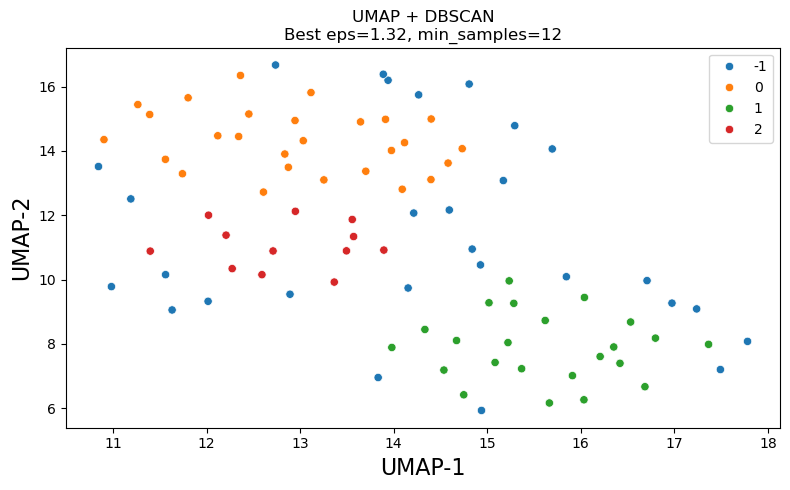

In [66]:
best_eps = best_run['eps']
best_min_samples = best_run['min_samples']
dbscan_final = DBSCAN(eps=best_eps, min_samples=int(best_min_samples))
final_labels = dbscan_final.fit_predict(X_umap)

# Visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=final_labels, palette='tab10')
plt.title(f"UMAP + DBSCAN\nBest eps={best_eps:.2f}, min_samples={int(best_min_samples)}")
plt.xlabel("UMAP-1", fontsize=16)
plt.ylabel("UMAP-2", fontsize=16)
plt.tight_layout()
plt.show()

Interpretation

In [43]:
from sklearn.cluster import KMeans, DBSCAN

# --- PCA + KMeans (k=4)
kmeans_pca_4 = KMeans(n_clusters=4, random_state=42)
labels_pca_k4 = kmeans_pca_4.fit_predict(X_pca_df)
tidy_df['PCA_KMeans_4'] = labels_pca_k4

# --- UMAP + KMeans (k=3)
kmeans_umap_3 = KMeans(n_clusters=3, random_state=42)
labels_umap_k3 = kmeans_umap_3.fit_predict(X_umap_best)
tidy_df['UMAP_KMeans_3'] = labels_umap_k3

# --- PCA + DBSCAN
dbscan_pca = DBSCAN(eps=2.8, min_samples=10)
labels_pca_db = dbscan_pca.fit_predict(X_pca_df)
tidy_df['PCA_DBSCAN'] = labels_pca_db  # Already exists, but overwrite to be sure

# --- UMAP + DBSCAN
dbscan_umap = DBSCAN(eps= 1.321429, min_samples=15)
labels_umap_db = dbscan_umap.fit_predict(X_umap_best)
tidy_df['UMAP_DBSCAN'] = labels_umap_db

In [44]:
# List only numeric columns
numeric_cols = tidy_df.select_dtypes(include='number').columns

# Define your clustering label columns with titles
cluster_methods = {
    'PCA_KMeans_4': 'PCA + KMeans (k=4)',
    'UMAP_KMeans_3': 'UMAP + KMeans (k=3)',
    'PCA_DBSCAN': 'PCA + DBSCAN (eps=2.8)',
    'UMAP_DBSCAN': 'UMAP + DBSCAN (eps=1.32)'
}

# Display cluster-wise means for numeric variables only
for label_col, title in cluster_methods.items():
    print(f"\n=== Cluster Characteristics: {title} ===")
    summary = tidy_df.groupby(label_col)[numeric_cols].mean()
    display(summary)


=== Cluster Characteristics: PCA + KMeans (k=4) ===


,Redshift,Distance (Mpc),Mass 1 (M☉),Mass 2 (M☉),Total Mass (M☉),Final Mass (M☉),Chirp Mass (M☉),SNR,Effective Spin,PCA_KMeans_3,PCA_KMeans_4,UMAP_KMeans_3,UMAP_KMeans_4,PCA_DBSCAN,UMAP_DBSCAN
PCA_KMeans_4,,,,,,,,,,,,,,,
0,0.165000,834.687500,15.620625,7.565938,23.302393,22.429549,8.874562,12.771875,0.054375,0.03125,0.0,0.000000,0.000000,-0.03125,1.000000
1,0.237778,1236.666667,37.077778,27.761111,64.745241,61.811111,27.605556,17.111111,0.012222,1.00000,1.0,1.833333,1.833333,0.00000,1.833333
2,0.743750,4792.500000,80.850000,45.400000,126.975000,121.162500,50.900000,10.625000,0.215000,2.00000,2.0,1.000000,1.500000,-0.50000,0.000000
3,0.540312,3225.937500,42.746875,26.625000,69.528666,66.396875,28.409375,9.581250,0.100625,1.25000,3.0,1.093750,1.687500,0.00000,0.156250



=== Cluster Characteristics: UMAP + KMeans (k=3) ===


,Redshift,Distance (Mpc),Mass 1 (M☉),Mass 2 (M☉),Total Mass (M☉),Final Mass (M☉),Chirp Mass (M☉),SNR,Effective Spin,PCA_KMeans_3,PCA_KMeans_4,UMAP_KMeans_3,UMAP_KMeans_4,PCA_DBSCAN,UMAP_DBSCAN
UMAP_KMeans_3,,,,,,,,,,,,,,,
0,0.173824,886.764706,16.234118,8.229706,24.593429,23.65134,9.479000,12.711765,0.051765,0.088235,0.117647,0.0,0.000000,-0.029412,1.0
1,0.598889,3668.333333,52.877778,31.836111,84.983223,81.12500,34.483333,9.902778,0.120000,1.444444,2.722222,1.0,1.611111,-0.111111,0.0
2,0.266500,1416.500000,36.320000,26.555000,62.811782,59.98500,26.675000,15.980000,0.041000,1.000000,1.400000,2.0,2.050000,0.000000,1.8



=== Cluster Characteristics: PCA + DBSCAN (eps=2.8) ===


,Redshift,Distance (Mpc),Mass 1 (M☉),Mass 2 (M☉),Total Mass (M☉),Final Mass (M☉),Chirp Mass (M☉),SNR,Effective Spin,PCA_KMeans_3,PCA_KMeans_4,UMAP_KMeans_3,UMAP_KMeans_4,PCA_DBSCAN,UMAP_DBSCAN
PCA_DBSCAN,,,,,,,,,,,,,,,
-1,0.676000,4442.000000,75.472000,43.094000,118.570817,113.260000,47.297200,14.160000,0.166000,1.600000,1.600000,0.800000,1.200000,-1.0,0.200000
0,0.346118,1980.352941,32.995294,20.488706,53.634755,51.271124,21.890588,12.205882,0.071412,0.788235,1.435294,0.847059,1.094118,0.0,0.811765



=== Cluster Characteristics: UMAP + DBSCAN (eps=1.32) ===


,Redshift,Distance (Mpc),Mass 1 (M☉),Mass 2 (M☉),Total Mass (M☉),Final Mass (M☉),Chirp Mass (M☉),SNR,Effective Spin,PCA_KMeans_3,PCA_KMeans_4,UMAP_KMeans_3,UMAP_KMeans_4,PCA_DBSCAN,UMAP_DBSCAN
UMAP_DBSCAN,,,,,,,,,,,,,,,
0,0.589474,3599.736842,51.978947,31.226316,83.470948,79.686842,33.871053,9.921053,0.120526,1.421053,2.736842,1.052632,1.657895,-0.105263,0.0
1,0.173824,886.764706,16.234118,8.229706,24.593429,23.651340,9.479000,12.711765,0.051765,0.088235,0.117647,0.000000,0.000000,-0.029412,1.0
2,0.249444,1311.111111,36.377778,27.255556,63.540868,60.672222,27.100000,16.616667,0.031111,1.000000,1.222222,2.000000,2.000000,0.000000,2.0


In [45]:
cluster_methods = ['PCA_KMeans_4', 'UMAP_KMeans_3', 'PCA_DBSCAN', 'UMAP_DBSCAN']

for method in cluster_methods:
    print(f"\n=== Cluster Counts for {method} ===")
    display(tidy_df[method].value_counts().sort_index())



=== Cluster Counts for PCA_KMeans_4 ===


PCA_KMeans_4
0    32
1    18
2     8
3    32
Name: count, dtype: int64


=== Cluster Counts for UMAP_KMeans_3 ===


UMAP_KMeans_3
0    34
1    36
2    20
Name: count, dtype: int64


=== Cluster Counts for PCA_DBSCAN ===


PCA_DBSCAN
-1     5
 0    85
Name: count, dtype: int64


=== Cluster Counts for UMAP_DBSCAN ===


UMAP_DBSCAN
0    38
1    34
2    18
Name: count, dtype: int64

In [46]:
cluster_methods = ['PCA_KMeans_4', 'UMAP_KMeans_3', 'PCA_DBSCAN', 'UMAP_DBSCAN']

for method in cluster_methods:
    print(f"\n=== Events per Cluster for {method} ===")
    grouped = tidy_df.groupby(method)['Event ID'].apply(list)
    for cluster_label, events in grouped.items():
        print(f"Cluster {cluster_label}: {len(events)} events")
        print(events)



=== Events per Cluster for PCA_KMeans_4 ===
Cluster 0: 32 events
['GW200316_215756-v1', 'GW200225_060421-v1', 'GW200210_092254-v1', 'GW200202_154313-v1', 'GW200115_042309-v2', 'GW191219_163120-v1', 'GW191216_213338-v1', 'GW191215_223052-v1', 'GW191204_171526-v1', 'GW191129_134029-v1', 'GW191126_115259-v1', 'GW191113_071753-v1', 'GW191105_143521-v1', 'GW191103_012549-v1', 'GW190930_133541-v2', 'GW190925_232845-v1', 'GW190924_021846-v2', 'GW190917_114630-v1', 'GW190828_065509-v2', 'GW190814_211039-v3', 'GW190728_064510-v2', 'GW190725_174728-v1', 'GW190720_000836-v2', 'GW190708_232457-v2', 'GW190707_093326-v2', 'GW190512_180714-v2', 'GW190425_081805-v3', 'GW190412_053044-v4', 'GW170817-v3', 'GW170608-v3', 'GW151226-v2', 'GW151012-v3']
Cluster 1: 18 events
['GW200311_115853-v1', 'GW200302_015811-v1', 'GW200224_222234-v1', 'GW200129_065458-v1', 'GW200112_155838-v1', 'GW191109_010717-v1', 'GW190915_235702-v2', 'GW190910_112807-v2', 'GW190828_063405-v2', 'GW190630_185205-v2', 'GW190521_07435

In [67]:
# Use the exact same embedding for both
X_umap_for_all = X_umap_best  # <- the one you chose as "best"
# Refit DBSCAN on this same embedding
dbscan_final = DBSCAN(eps=best_eps, min_samples=int(best_min_samples))
final_labels = dbscan_final.fit_predict(X_umap_for_all)


In [68]:
import numpy as np
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

# Reference labels (from UMAP + KMeans k=3)
y_ref = np.asarray(tidy_df['UMAP_KMeans_3'])

# Predicted labels (from DBSCAN on the SAME embedding)
y_pred = final_labels.copy()

# Build contingency matrix ignoring noise (-1)
mask = (y_pred != -1)
cm = confusion_matrix(y_ref[mask], y_pred[mask])  # rows: ref, cols: pred

# Find best one-to-one mapping (maximize overlap)
row_ind, col_ind = linear_sum_assignment(-cm)     # maximize by negating
mapping = {col: row for row, col in zip(row_ind, col_ind)}

# Apply mapping; keep noise as -1
y_pred_aligned = np.full_like(y_pred, fill_value=-1)
for old, new in mapping.items():
    y_pred_aligned[y_pred == old] = new


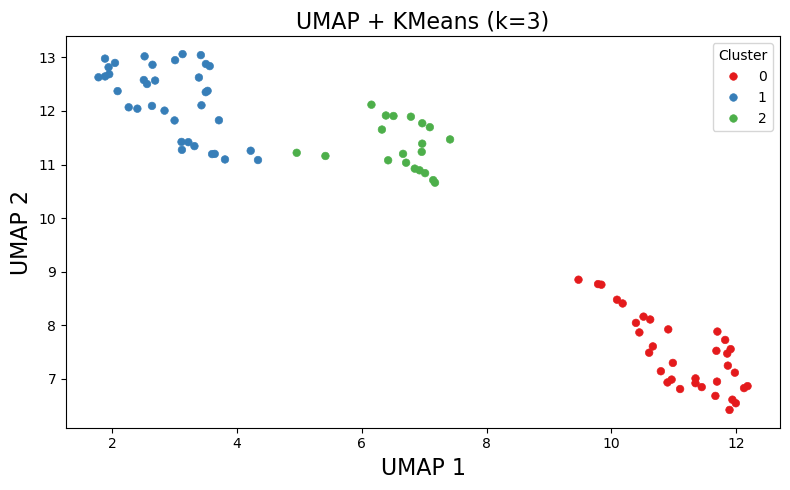

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {0:"#e41a1c", 1:"#377eb8", 2:"#4daf4a", -1:"#999999"}  # Set1-ish + gray for noise
hue_order_k = [0,1,2]
hue_order_d = [0,1,2,-1]

# UMAP + KMeans (k=3)
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_umap_for_all[:,0], y=X_umap_for_all[:,1],
                hue=y_ref, hue_order=hue_order_k, palette=palette, s=30, edgecolor=None)
plt.title("UMAP + KMeans (k=3)", fontsize=16)
plt.xlabel("UMAP 1", fontsize=16); plt.ylabel("UMAP 2", fontsize=16)
plt.legend(title='Cluster'); plt.tight_layout(); plt.show()

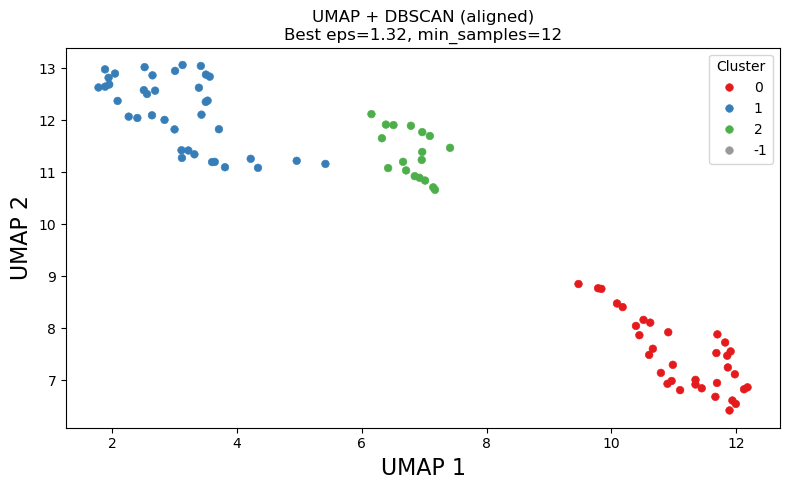

In [71]:
# UMAP + DBSCAN (aligned to KMeans labels)
plt.figure(figsize=(8,5))
sns.scatterplot(x=X_umap_for_all[:,0], y=X_umap_for_all[:,1],
                hue=y_pred_aligned, hue_order=hue_order_d, palette=palette, s=30, edgecolor=None)
plt.title(f"UMAP + DBSCAN (aligned)\nBest eps={best_eps:.2f}, min_samples={int(best_min_samples)}")
plt.xlabel("UMAP 1", fontsize=16); plt.ylabel("UMAP 2", fontsize=16)
plt.legend(title='Cluster'); plt.tight_layout(); plt.show()
